Problem 1.a

In [1]:
!pip install spectral
!pip install scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset Information:
Image dimensions: 1039 lines × 1087 samples
Number of bands: 272
Wavelength range: 398.57 - 1001.81 nm
Electromagnetic range: Visible to Near-Infrared (VIS-NIR)
Spectral resolution: ~2.23 nm

Selected bands:
Blue: Band 23, 449.77 nm
Green: Band 68, 549.94 nm
Red: Band 113, 650.11 nm
NIR: Band 180, 799.25 nm



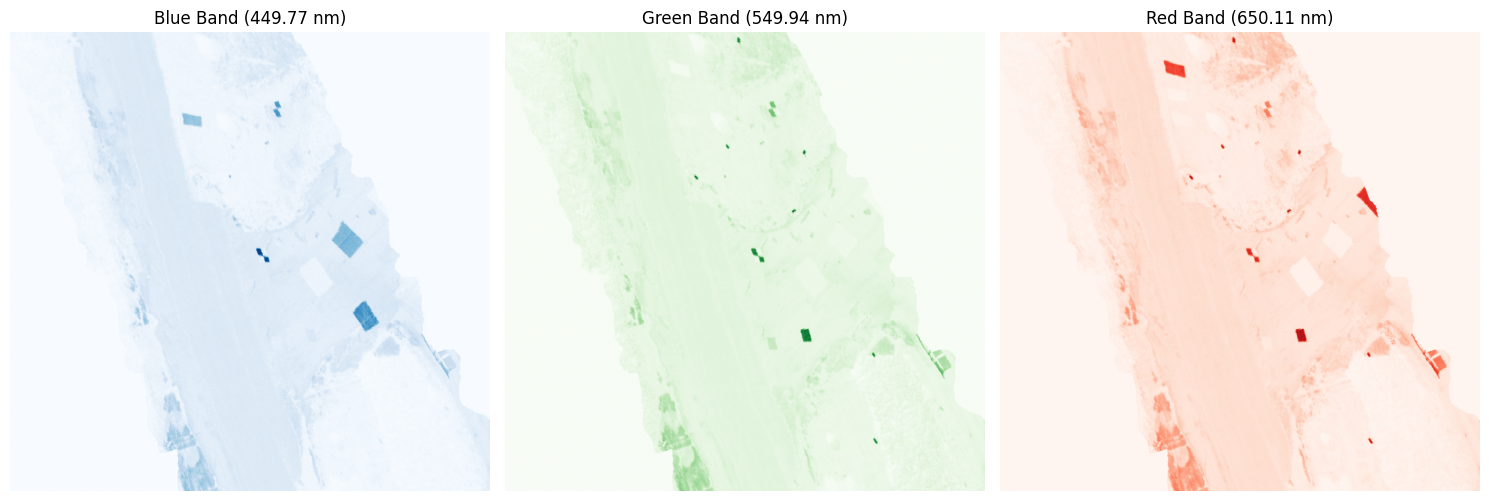

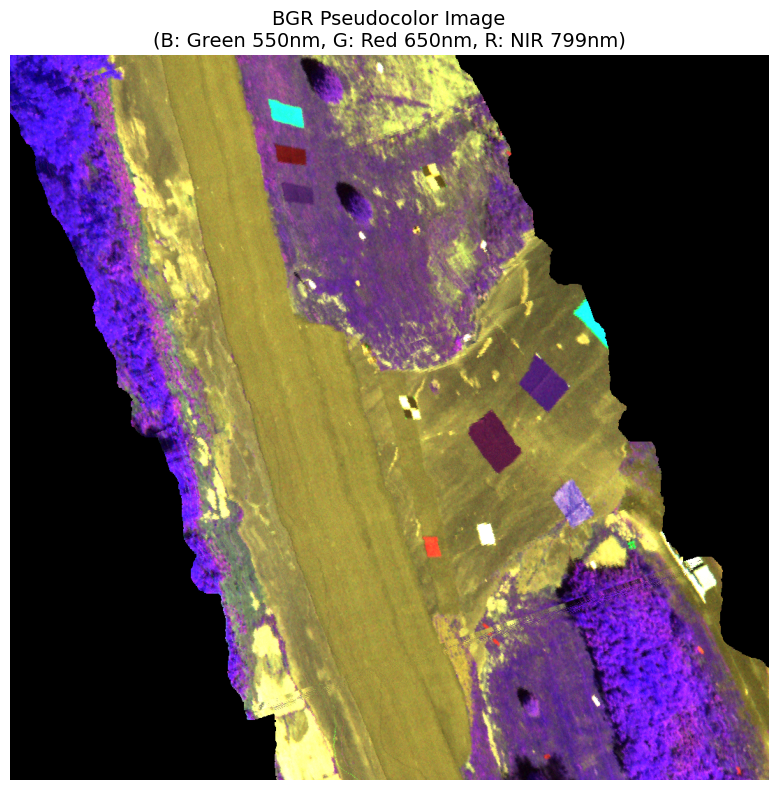


NIR bands:
~900 nm: Band 225, 899.42 nm
~950 nm: Band 248, 950.62 nm
~1000 nm: Band 270, 999.59 nm


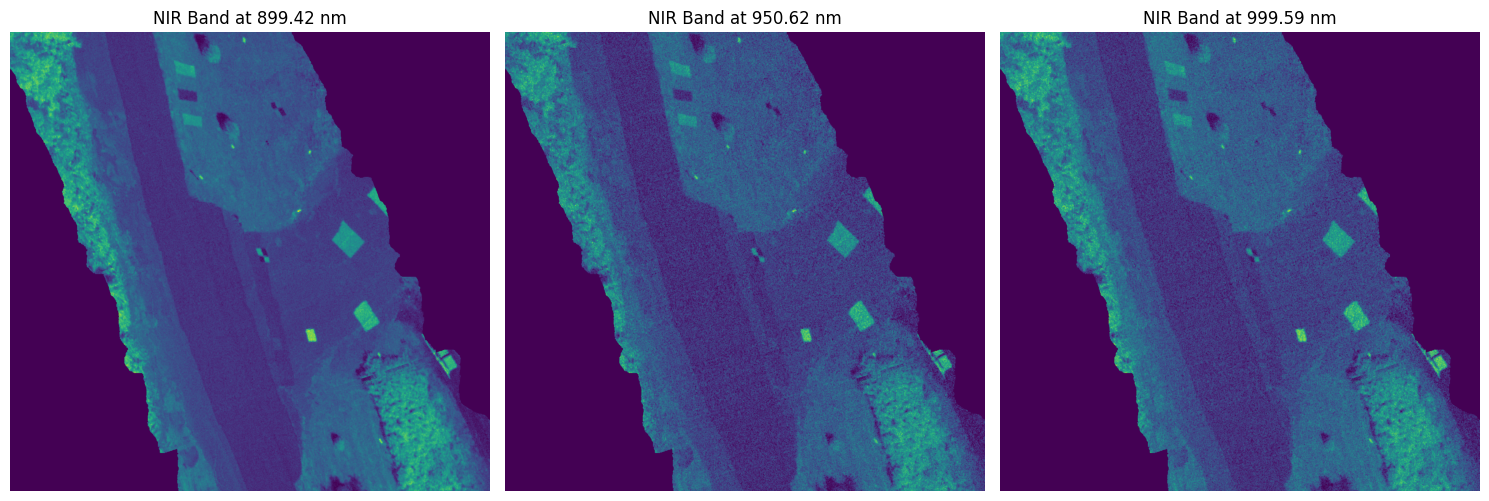

In [9]:
from spectral import *
import numpy as np
import matplotlib.pyplot as plt
import re

# Load the ENVI file
img = envi.open('tait_labsphere.hdr', 'tait_labsphere')
data = img.load()

# Extract wavelengths from band names
wavelengths = []
for band_name in img.metadata['band names']:
    match = re.search(r'(\d+\.?\d*)\s*nm', band_name)
    if match:
        wavelengths.append(float(match.group(1)))

wavelengths = np.array(wavelengths)

print(f"Dataset Information:")
print(f"Image dimensions: {data.shape[0]} lines × {data.shape[1]} samples")
print(f"Number of bands: {data.shape[2]}")
print(f"Wavelength range: {wavelengths[0]:.2f} - {wavelengths[-1]:.2f} nm")
print(f"Electromagnetic range: Visible to Near-Infrared (VIS-NIR)")
print(f"Spectral resolution: ~{np.mean(np.diff(wavelengths)):.2f} nm\n")

# Function to find the closest band to a target wavelength
def find_band(target_wl, wavelengths):
    idx = np.argmin(np.abs(wavelengths - target_wl))
    return idx, wavelengths[idx]

# Find bands for blue, green, red
blue_idx, blue_wl = find_band(450, wavelengths)
green_idx, green_wl = find_band(550, wavelengths)
red_idx, red_wl = find_band(650, wavelengths)
nir_idx, nir_wl = find_band(800, wavelengths)

print(f"Selected bands:")
print(f"Blue: Band {blue_idx}, {blue_wl:.2f} nm")
print(f"Green: Band {green_idx}, {green_wl:.2f} nm")
print(f"Red: Band {red_idx}, {red_wl:.2f} nm")
print(f"NIR: Band {nir_idx}, {nir_wl:.2f} nm\n")

# 1. Show blue, green, and red bands in one plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(data[:, :, blue_idx], cmap='Blues')
axes[0].set_title(f'Blue Band ({blue_wl:.2f} nm)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(data[:, :, green_idx], cmap='Greens')
axes[1].set_title(f'Green Band ({green_wl:.2f} nm)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(data[:, :, red_idx], cmap='Reds')
axes[2].set_title(f'Red Band ({red_wl:.2f} nm)', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 2. Create BGR pseudocolor image (Green-Red-NIR as BGR)
# Stack green, red, NIR and normalize
bgr_image = np.dstack([data[:, :, green_idx],
                       data[:, :, red_idx],
                       data[:, :, nir_idx]])

# Normalize to 0-1 range for display
bgr_normalized = np.zeros_like(bgr_image)
for i in range(3):
    band = bgr_image[:, :, i]
    # Use percentile stretching for better contrast
    p2, p98 = np.percentile(band, (2, 98))
    bgr_normalized[:, :, i] = np.clip((band - p2) / (p98 - p2), 0, 1)

plt.figure(figsize=(10, 8))
plt.imshow(bgr_normalized)
plt.title(f'BGR Pseudocolor Image\n(B: Green {green_wl:.0f}nm, G: Red {red_wl:.0f}nm, R: NIR {nir_wl:.0f}nm)',
          fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

# 3. Plot bands at 900, 950, and 1000 nm in separate plots
band_900_idx, wl_900 = find_band(900, wavelengths)
band_950_idx, wl_950 = find_band(950, wavelengths)
band_1000_idx, wl_1000 = find_band(1000, wavelengths)

print(f"\nNIR bands:")
print(f"~900 nm: Band {band_900_idx}, {wl_900:.2f} nm")
print(f"~950 nm: Band {band_950_idx}, {wl_950:.2f} nm")
print(f"~1000 nm: Band {band_1000_idx}, {wl_1000:.2f} nm")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(data[:, :, band_900_idx], cmap='viridis')
axes[0].set_title(f'NIR Band at {wl_900:.2f} nm', fontsize=12)
axes[0].axis('off')

axes[1].imshow(data[:, :, band_950_idx], cmap='viridis')
axes[1].set_title(f'NIR Band at {wl_950:.2f} nm', fontsize=12)
axes[1].axis('off')

axes[2].imshow(data[:, :, band_1000_idx], cmap='viridis')
axes[2].set_title(f'NIR Band at {wl_1000:.2f} nm', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

Explanation: By employing the near-infrared band, which is especially sensitive to vegetation health and water content, the pseudocolor composite (using Green at 550 nm, Red at 650 nm, and NIR at 799 nm mapped to blue, green, and red channels respectively) improves the contrast between various land cover types.  As a result, distinct surface characteristics are far easier to identify than they would be in the first image's individual true-color bands.

In contrast to the pale, washed-out visible bands, the NIR bands exhibit noticeably greater contrast and feature clarity.  Water bodies appear as dark purple/black in NIR (strong absorption) versus faint subtle tones in visible wavelengths, while vegetation appears as vibrant cyan/green in NIR (due to high chlorophyll reflectance) versus hardly distinguishable in the visible bands.  In the visible bands, agricultural fields and land use patterns blend together almost indistinguishably, but in the NIR images, they stand out clearly with distinct boundaries.  The appearance of all three NIR bands (899–1000 nm) is strikingly similar, indicating uniform material characteristics throughout this spectral range.


Problem 1.b

Original shape: (1039, 1087, 272)
Reshaped for correlation: (1129393, 272)
Computing correlation matrix for 272 bands...
Correlation matrix shape: (272, 272)
Correlation range: [0.281, 1.000]


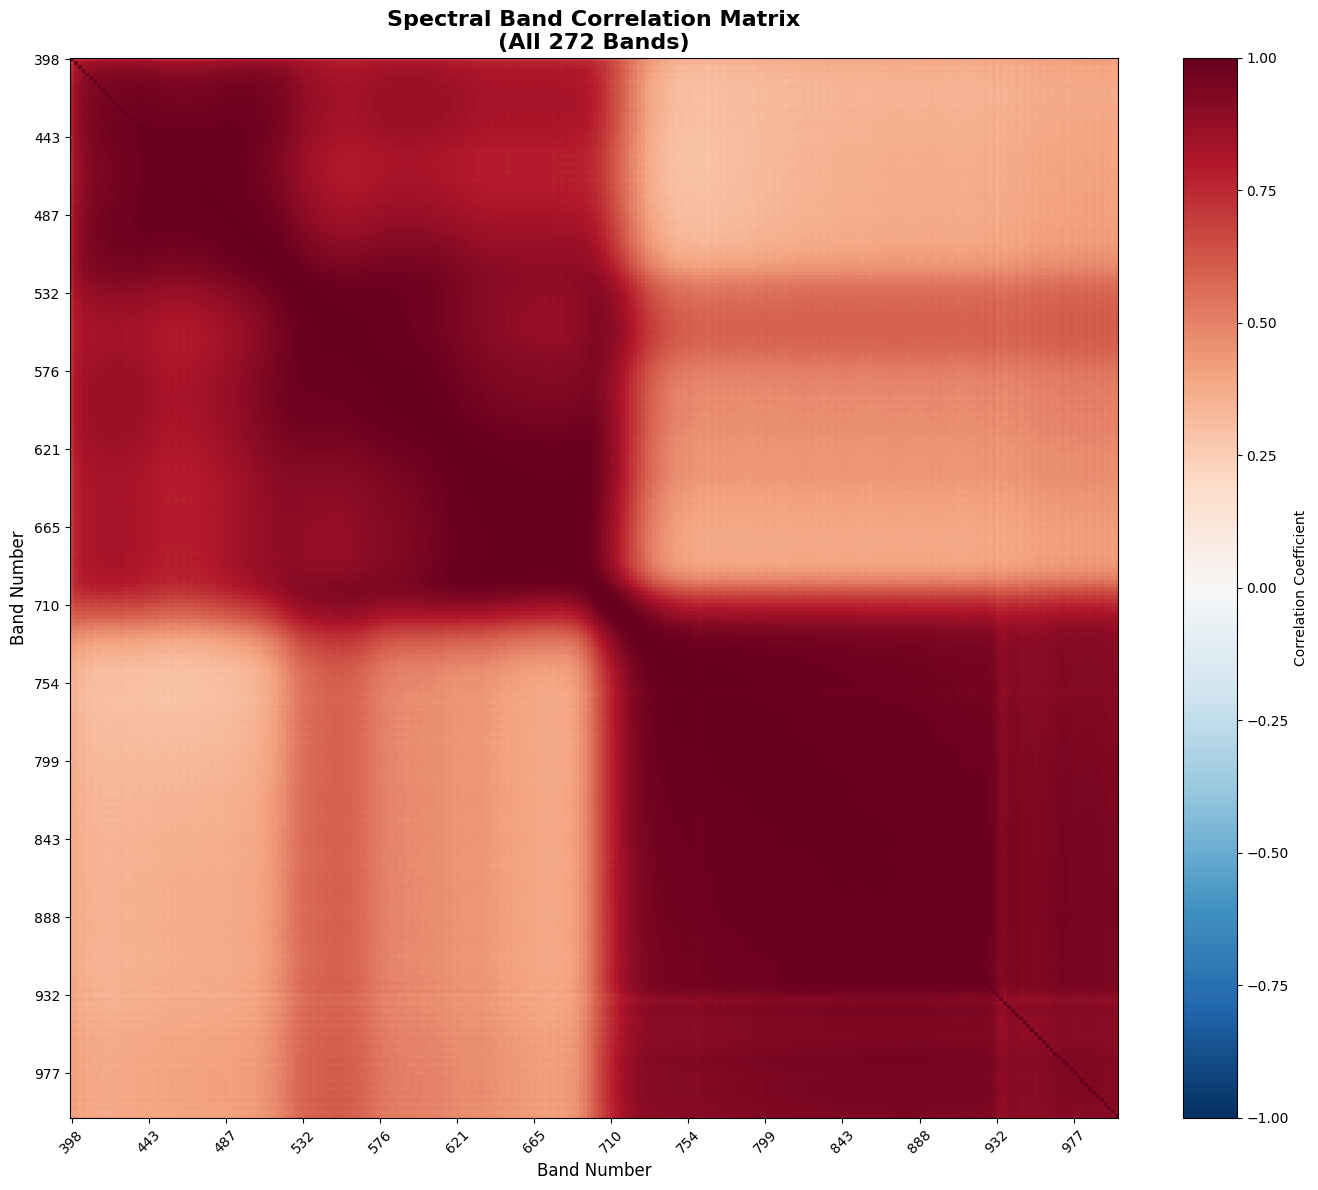

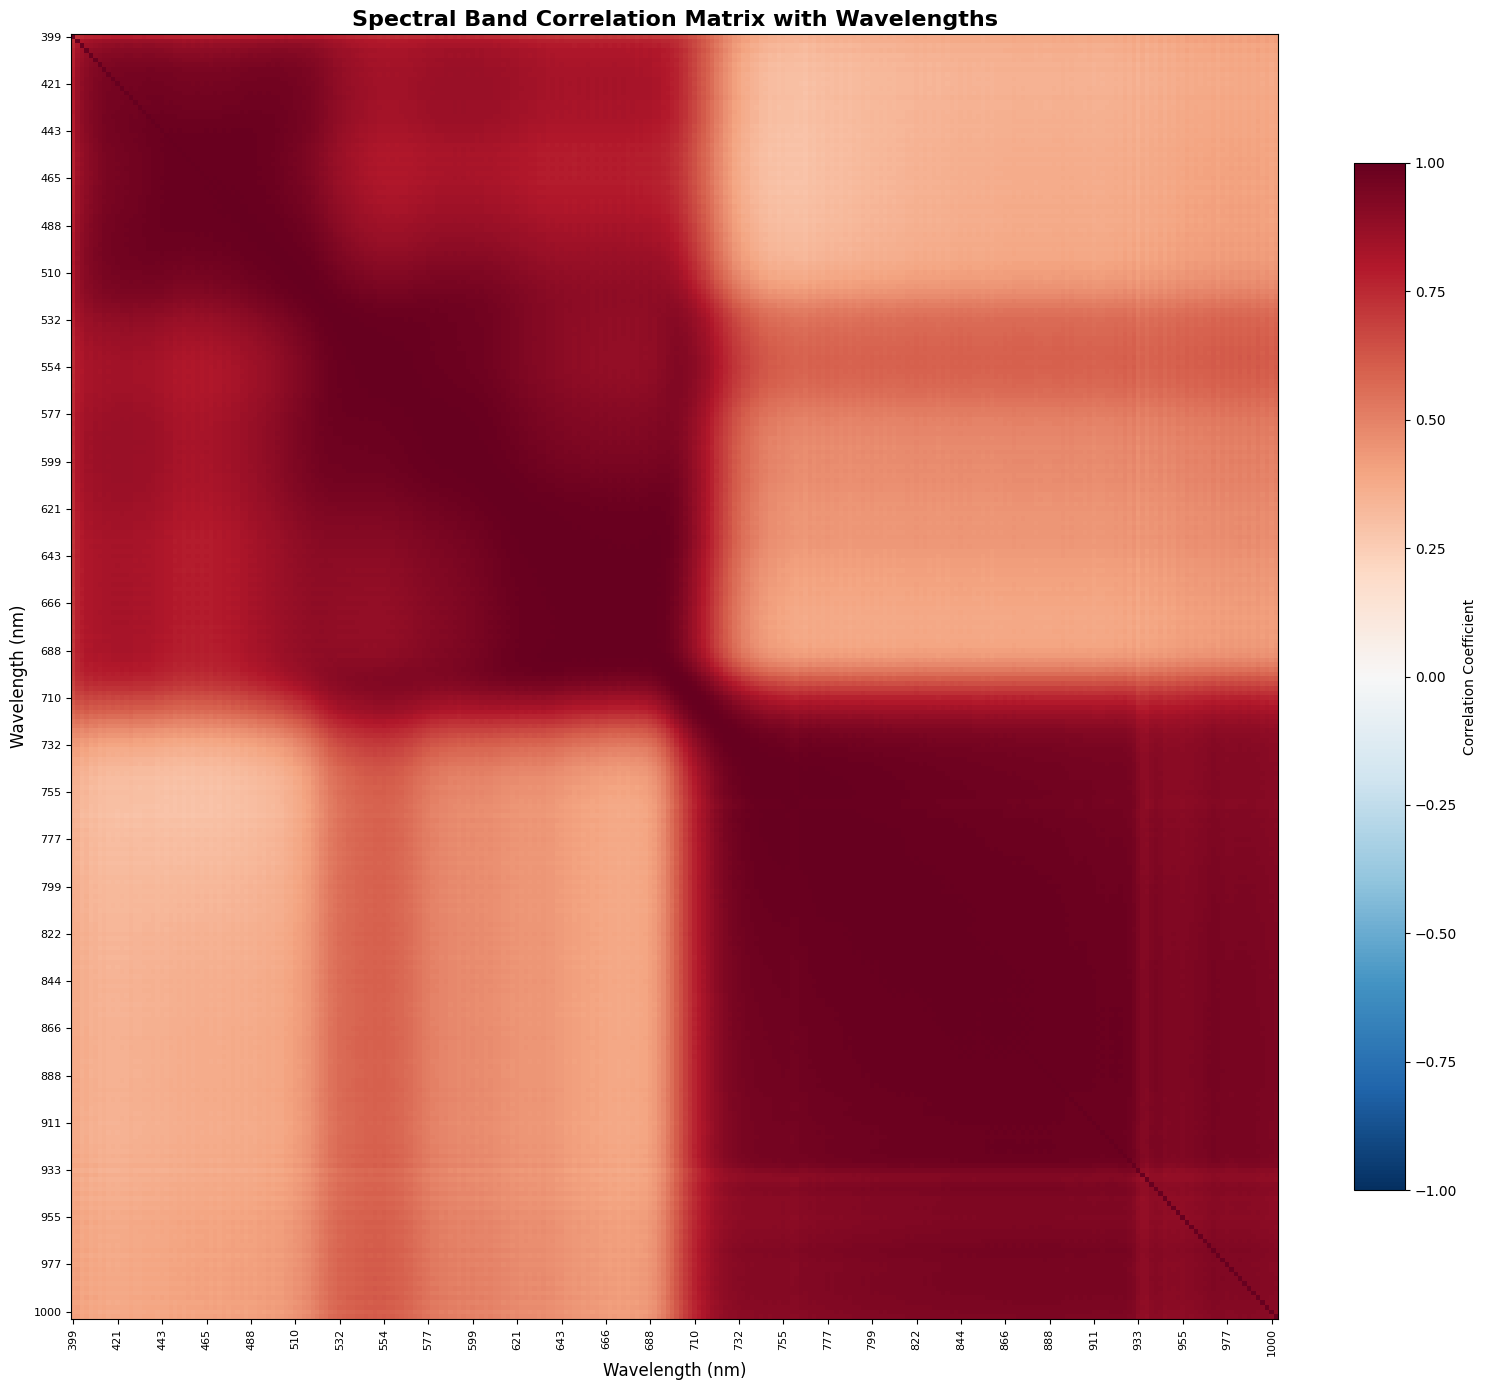


CORRELATION ANALYSIS

Descriptive Statistics:
Mean correlation: 0.6905
Median correlation: 0.7679
Std deviation: 0.2467
Min correlation: 0.2807
Max correlation: 0.9975


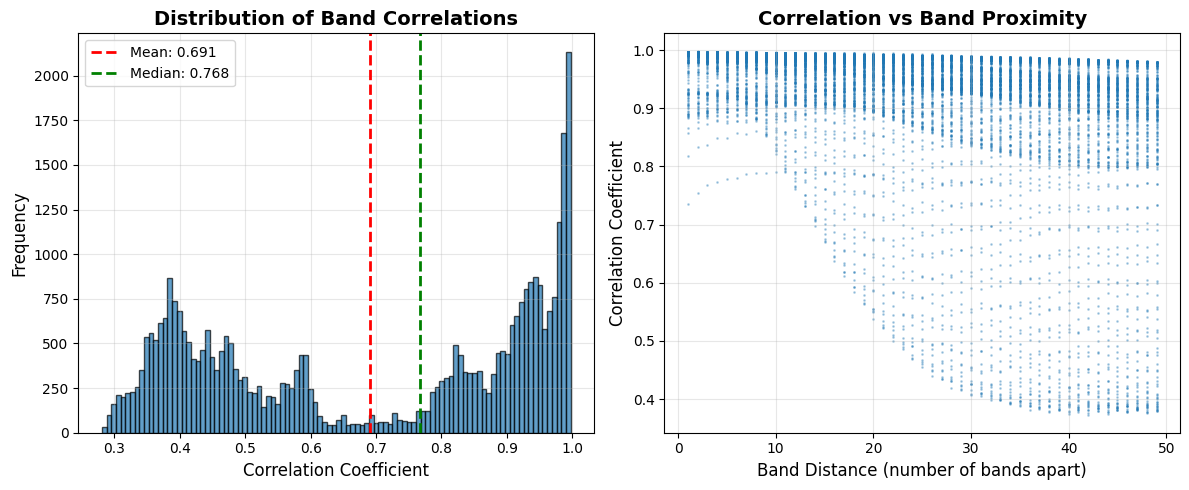


------------------------------------------------------------
HIGHLY CORRELATED BAND PAIRS (r > 0.99):
------------------------------------------------------------
Band 24 (452.0nm) & Band 30 (465.4nm): r = 0.9901
Band 24 (452.0nm) & Band 32 (469.8nm): r = 0.9902
Band 25 (454.2nm) & Band 27 (458.7nm): r = 0.9902
Band 25 (454.2nm) & Band 29 (463.1nm): r = 0.9907
Band 25 (454.2nm) & Band 30 (465.4nm): r = 0.9902
Band 25 (454.2nm) & Band 31 (467.6nm): r = 0.9908
Band 25 (454.2nm) & Band 32 (469.8nm): r = 0.9902
Band 25 (454.2nm) & Band 33 (472.0nm): r = 0.9906
Band 26 (456.4nm) & Band 28 (460.9nm): r = 0.9902
Band 26 (456.4nm) & Band 30 (465.4nm): r = 0.9906

------------------------------------------------------------
WEAKLY CORRELATED BAND PAIRS (r < 0.5):
------------------------------------------------------------
Band 25 (454.2nm) & Band 165 (765.9nm): r = 0.2807
Band 27 (458.7nm) & Band 165 (765.9nm): r = 0.2811
Band 21 (445.3nm) & Band 165 (765.9nm): r = 0.2817
Band 23 (449.8nm) & 

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from spectral import *


img = envi.open('tait_labsphere.hdr', 'tait_labsphere')
data = img.load()

# Reshape data for correlation analysis
# From (lines, samples, bands) to (pixels, bands)
n_lines, n_samples, n_bands = data.shape
data_reshaped = data.reshape(n_lines * n_samples, n_bands)

print(f"Original shape: {data.shape}")
print(f"Reshaped for correlation: {data_reshaped.shape}")
print(f"Computing correlation matrix for {n_bands} bands...")

# Compute correlation matrix
correlation_matrix = np.corrcoef(data_reshaped.T)

print(f"Correlation matrix shape: {correlation_matrix.shape}")
print(f"Correlation range: [{correlation_matrix.min():.3f}, {correlation_matrix.max():.3f}]")

# Extract wavelengths for axis labels
import re
wavelengths = []
for band_name in img.metadata['band names']:
    match = re.search(r'(\d+\.?\d*)\s*nm', band_name)
    if match:
        wavelengths.append(float(match.group(1)))
wavelengths = np.array(wavelengths)

# 1. Display full correlation matrix
plt.figure(figsize=(14, 12))
im = plt.imshow(correlation_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, label='Correlation Coefficient')
plt.title('Spectral Band Correlation Matrix\n(All 272 Bands)', fontsize=16, fontweight='bold')
plt.xlabel('Band Number', fontsize=12)
plt.ylabel('Band Number', fontsize=12)

# Add wavelength information on axes
tick_positions = np.arange(0, n_bands, 20)
tick_labels = [f'{int(wavelengths[i])}' for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45)
plt.yticks(tick_positions, tick_labels)

plt.tight_layout()
plt.show()

# 2. Display correlation matrix with wavelength labels (every 10th band)
plt.figure(figsize=(16, 14))
im = plt.imshow(correlation_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
cbar = plt.colorbar(im, label='Correlation Coefficient', shrink=0.8)
cbar.ax.tick_params(labelsize=10)
plt.title('Spectral Band Correlation Matrix with Wavelengths', fontsize=16, fontweight='bold')
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Wavelength (nm)', fontsize=12)

# Add wavelength labels
tick_positions = np.arange(0, n_bands, 10)
tick_labels = [f'{wavelengths[i]:.0f}' for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=90, fontsize=8)
plt.yticks(tick_positions, tick_labels, fontsize=8)

plt.tight_layout()
plt.show()

# 3. Analyze correlation statistics
print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Get upper triangle (excluding diagonal)
upper_triangle = np.triu(correlation_matrix, k=1)
correlations = upper_triangle[upper_triangle != 0]

print(f"\nDescriptive Statistics:")
print(f"Mean correlation: {correlations.mean():.4f}")
print(f"Median correlation: {np.median(correlations):.4f}")
print(f"Std deviation: {correlations.std():.4f}")
print(f"Min correlation: {correlations.min():.4f}")
print(f"Max correlation: {correlations.max():.4f}")

# 4. Distribution of correlations
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(correlations, bins=100, edgecolor='black', alpha=0.7)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Band Correlations', fontsize=14, fontweight='bold')
plt.axvline(correlations.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {correlations.mean():.3f}')
plt.axvline(np.median(correlations), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(correlations):.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Correlation vs band distance
plt.subplot(1, 2, 2)
band_distances = []
correlation_values = []

for i in range(n_bands):
    for j in range(i+1, min(i+50, n_bands)):  # Look at nearby bands
        band_distances.append(j - i)
        correlation_values.append(correlation_matrix[i, j])

plt.scatter(band_distances, correlation_values, alpha=0.3, s=1)
plt.xlabel('Band Distance (number of bands apart)', fontsize=12)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.title('Correlation vs Band Proximity', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Find highly correlated and uncorrelated band pairs
print(f"\n" + "-"*60)
print("HIGHLY CORRELATED BAND PAIRS (r > 0.99):")
print("-"*60)
high_corr_threshold = 0.99
count = 0
for i in range(n_bands):
    for j in range(i+1, n_bands):
        if correlation_matrix[i, j] > high_corr_threshold:
            if count < 10:  # Show first 10
                print(f"Band {i} ({wavelengths[i]:.1f}nm) & Band {j} ({wavelengths[j]:.1f}nm): r = {correlation_matrix[i, j]:.4f}")
                count += 1

print(f"\n" + "-"*60)
print("WEAKLY CORRELATED BAND PAIRS (r < 0.5):")
print("-"*60)
weak_pairs = []
for i in range(n_bands):
    for j in range(i+1, n_bands):
        if correlation_matrix[i, j] < 0.5:
            weak_pairs.append((i, j, correlation_matrix[i, j]))

weak_pairs.sort(key=lambda x: x[2])
for i, j, corr in weak_pairs[:10]:  # Show 10 least correlated
    print(f"Band {i} ({wavelengths[i]:.1f}nm) & Band {j} ({wavelengths[j]:.1f}nm): r = {corr:.4f}")



Explanation: Spectral bands in the same region (visible or NIR) exhibit strong correlation, whereas bands in different regions exhibit weaker correlation, according to the correlation matrix's clear block-diagonal patterns.  Because of their fundamentally different interactions with vegetation—chlorophyll strongly absorbs red light while reflecting NIR—the visible and NIR bands decorrelate sharply in the lighter transition zone around band 710 nm (the "red edge").  All of the bands in the NIR region (lower-right quadrant) exhibit extremely high correlation, which explains why the three NIR images appeared almost identical and included redundant data.  The bands that are visible (upper-left) also have a strong correlation with one another.